In [10]:
"""Flux-schnell Prompt-based Image Editing (4 steps)

Based on: "Exploring Multimodal Diffusion Transformers for Enhanced Prompt-based Image Editing"
"""

import torch
import matplotlib.pyplot as plt
from diffusers import FluxPipeline

import sys
sys.path.append("..")
from utils import (
    register_qkv_control,
    create_qkv_controller,
    p2p_callback,
    TOP5_BLOCKS,
)

pipe = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-schnell", torch_dtype=torch.bfloat16
).to("cuda")

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 12.94it/s]


Registered 57 attention processors (SDPA: True).


100%|██████████| 4/4 [00:06<00:00,  1.66s/it]


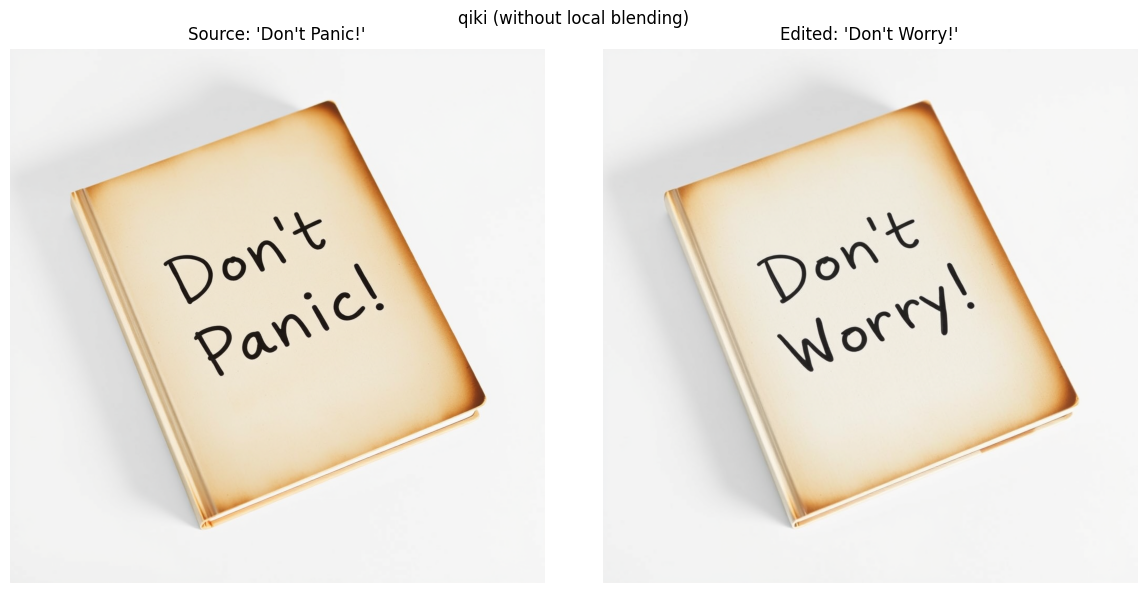

In [3]:
# Replace (qiki) - without local blending

prompts = [
    "a book with the words 'Don't Panic!' written on it", 
    "a book with the words 'Don't Worry!' written on it"
]
height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=4,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    replace_steps=0.25,  # only change at the first step (4 * 0.25 = 1)
    replace_blocks=list(range(38)),  # ~38 blocks for few-step Flux
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=4,
    guidance_scale=0.0,  # Schnell uses no guidance
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: 'Don't Panic!'")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: 'Don't Worry!'")
ax[1].axis("off")
plt.suptitle("qiki (without local blending)")
plt.tight_layout()

Registered 57 attention processors (SDPA: True).


100%|██████████| 4/4 [00:06<00:00,  1.72s/it]


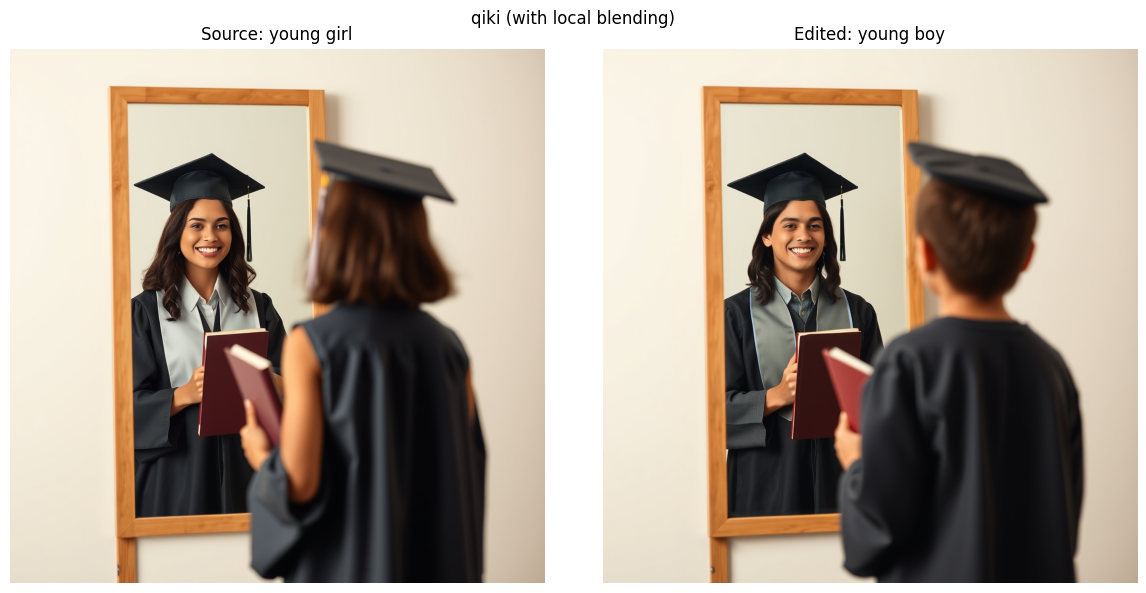

In [4]:
# Replace (qiki) - with local blending

prompts = [
    "An 8K DSLR image of the back of a young girl holding a thick book and standing in front of a mirror. In the reflection of the mirror, a grown woman wearing a graduation cap and gown is smiling confidently. The setting is softly lit with a motivational and aspirational aesthetic, emphasizing the contrast between the present and the future self.",
    "An 8K DSLR image of the back of a young boy holding a thick book and standing in front of a mirror. In the reflection of the mirror, a grown man wearing a graduation cap and gown is smiling confidently. The setting is softly lit with a motivational and aspirational aesthetic, emphasizing the contrast between the present and the future self.",
]

height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

controller = create_qkv_controller(
    pipeline_type="flux",
    prompts=prompts,
    num_inference_steps=4,
    tokenizer=tokenizers,
    device=pipe.device,
    dtype=pipe.dtype,
    method="qiki",
    replace_steps=0.25,  # only change at the first step (4 * 0.25 = 1)
    replace_blocks=list(range(38)),  # ~38 blocks for few-step Flux
    local_blend_words=[['young girl', 'grown woman'], ['young boy', 'grown man']],
    local_blend_threshold=0.3,
    aggregate_blocks=TOP5_BLOCKS["flux-schnell"],
    t5_max_seq_len=512,
    height=height,
    width=width,
)

register_qkv_control(pipe, controller)
images = pipe(
    prompt=prompts,
    num_inference_steps=4,
    guidance_scale=0.0,  # Schnell uses no guidance
    height=height,
    width=width,
    max_sequence_length=512,
    generator=[torch.Generator().manual_seed(1234888), torch.Generator().manual_seed(1234888)],
    callback_on_step_end=p2p_callback,
    callback_on_step_end_tensor_inputs=["latents"],
).images

controller.reset()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(images[0])
ax[0].set_title("Source: young girl")
ax[0].axis("off")
ax[1].imshow(images[1])
ax[1].set_title("Edited: young boy")
ax[1].axis("off")
plt.suptitle("qiki (with local blending)")
plt.tight_layout()

Registered 57 attention processors (SDPA: True).


100%|██████████| 4/4 [00:06<00:00,  1.68s/it]


Registered 57 attention processors (SDPA: True).


100%|██████████| 4/4 [00:06<00:00,  1.69s/it]


Registered 57 attention processors (SDPA: True).


100%|██████████| 4/4 [00:06<00:00,  1.70s/it]


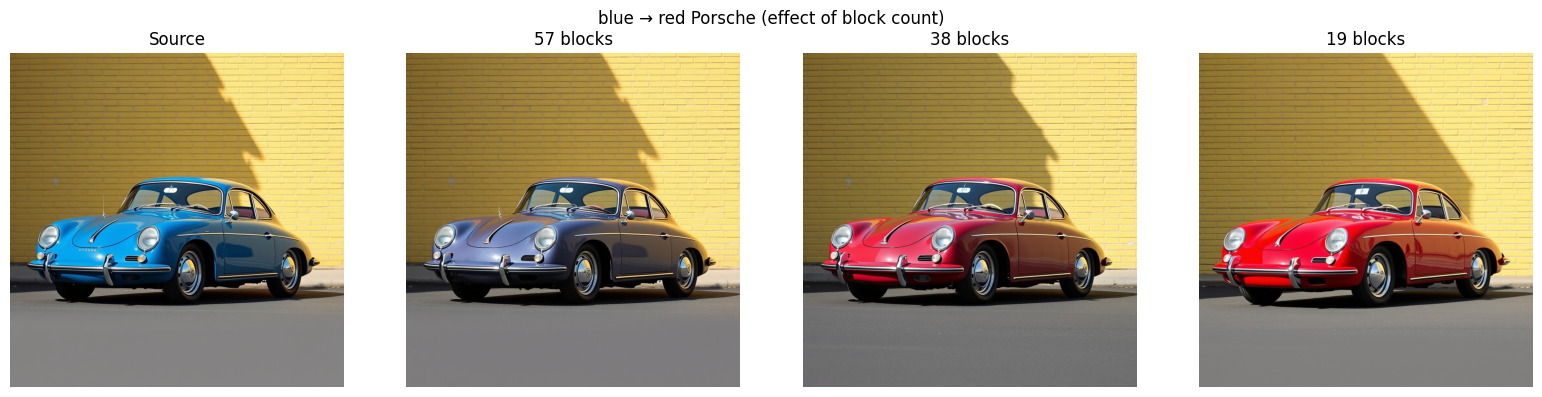

In [5]:
# Block count comparison (no local blending)
# In few-step models, replacing all 57 blocks makes the result resemble the source too much.
# We find that ~38 blocks works well for Flux-schnell.

prompts = [
    "A blue Porsche 356 parked in front of a yellow brick wall",
    "A red Porsche 356 parked in front of a yellow brick wall",
]
height, width = 1024, 1024
tokenizers = [pipe.tokenizer, pipe.tokenizer_2]

block_counts = [57, 38, 19]
results = {"source": None}

for n_blocks in block_counts:
    controller = create_qkv_controller(
        pipeline_type="flux",
        prompts=prompts,
        num_inference_steps=4,
        tokenizer=tokenizers,
        device=pipe.device,
        dtype=pipe.dtype,
        method="qiki",
        replace_steps=0.25,
        replace_blocks=list(range(n_blocks)),
        t5_max_seq_len=512,
        height=height,
        width=width,
    )
    register_qkv_control(pipe, controller)
    imgs = pipe(
        prompt=prompts,
        num_inference_steps=4,
        guidance_scale=0.0,
        height=height,
        width=width,
        max_sequence_length=512,
        generator=[torch.Generator().manual_seed(864), torch.Generator().manual_seed(864)],
        callback_on_step_end=p2p_callback,
        callback_on_step_end_tensor_inputs=["latents"],
    ).images
    controller.reset()
    
    if results["source"] is None:
        results["source"] = imgs[0]
    results[f"{n_blocks} blocks"] = imgs[1]

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(results["source"])
ax[0].set_title("Source")
ax[0].axis("off")
for i, n_blocks in enumerate(block_counts):
    ax[i+1].imshow(results[f"{n_blocks} blocks"])
    ax[i+1].set_title(f"{n_blocks} blocks")
    ax[i+1].axis("off")
plt.suptitle("blue → red Porsche (effect of block count)")
plt.tight_layout()

In [11]:
del pipe
torch.cuda.empty_cache()
print("Done!")

Done!
